# Frequency Level Diagram

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2')
sys.path.insert(1, 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks')
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from meas_utils import MultimodeStation
from calibration_helpers import (
    init_helpers,
    do_tof, update_tof,
    do_res_spec, update_res_spec,
    do_single_shot, update_single_shot,
)

station = MultimodeStation(
    experiment_name  = '2600403_lmm',
    hardware_config  = 'hardware_config_20260111.yml',
)
init_helpers(station)
config_thisrun = station.config_thisrun
cfg_dict       = station.cfg_dict
meas           = station.meas
print('Station ready.')

No module named 'visa.six.moves'
Warning VISA library import failed
Warning serial library import failed.
Could not load InstrumentManagerWindow
Could not import QickInstrument, try install qick package
Could not load AD5780 dac 
Could not load labbrick
Could not load Autonics TM4 Driver
Could not load Oxford Trition driver
Directory created at: S:\Multimode\experiment\2600403_lmm\plots\autocalibration_2026-04-14
connected proxies, ns= <Pyro4.core.Proxy at 0x21b61d1ea50; connected IPv4; for PYRO:Pyro.NameServer@10.108.30.32:9090>
Path added at highest priority
['C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2', 'C:\\Users\\Administrator\\Documents\\multimode_expts_tprocv2\\measurement_notebooks', 'C:\\_Lib\\python', 'C:\\_Lib\\python\\slab', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\python313.zip', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\DLLs', 'c:\\ProgramData\\Anaconda3\\envs\\mm313\\Lib', 'c:\\ProgramData

fname  frequency_level_diagram.png
fname  frequency_level_diagram.pdf


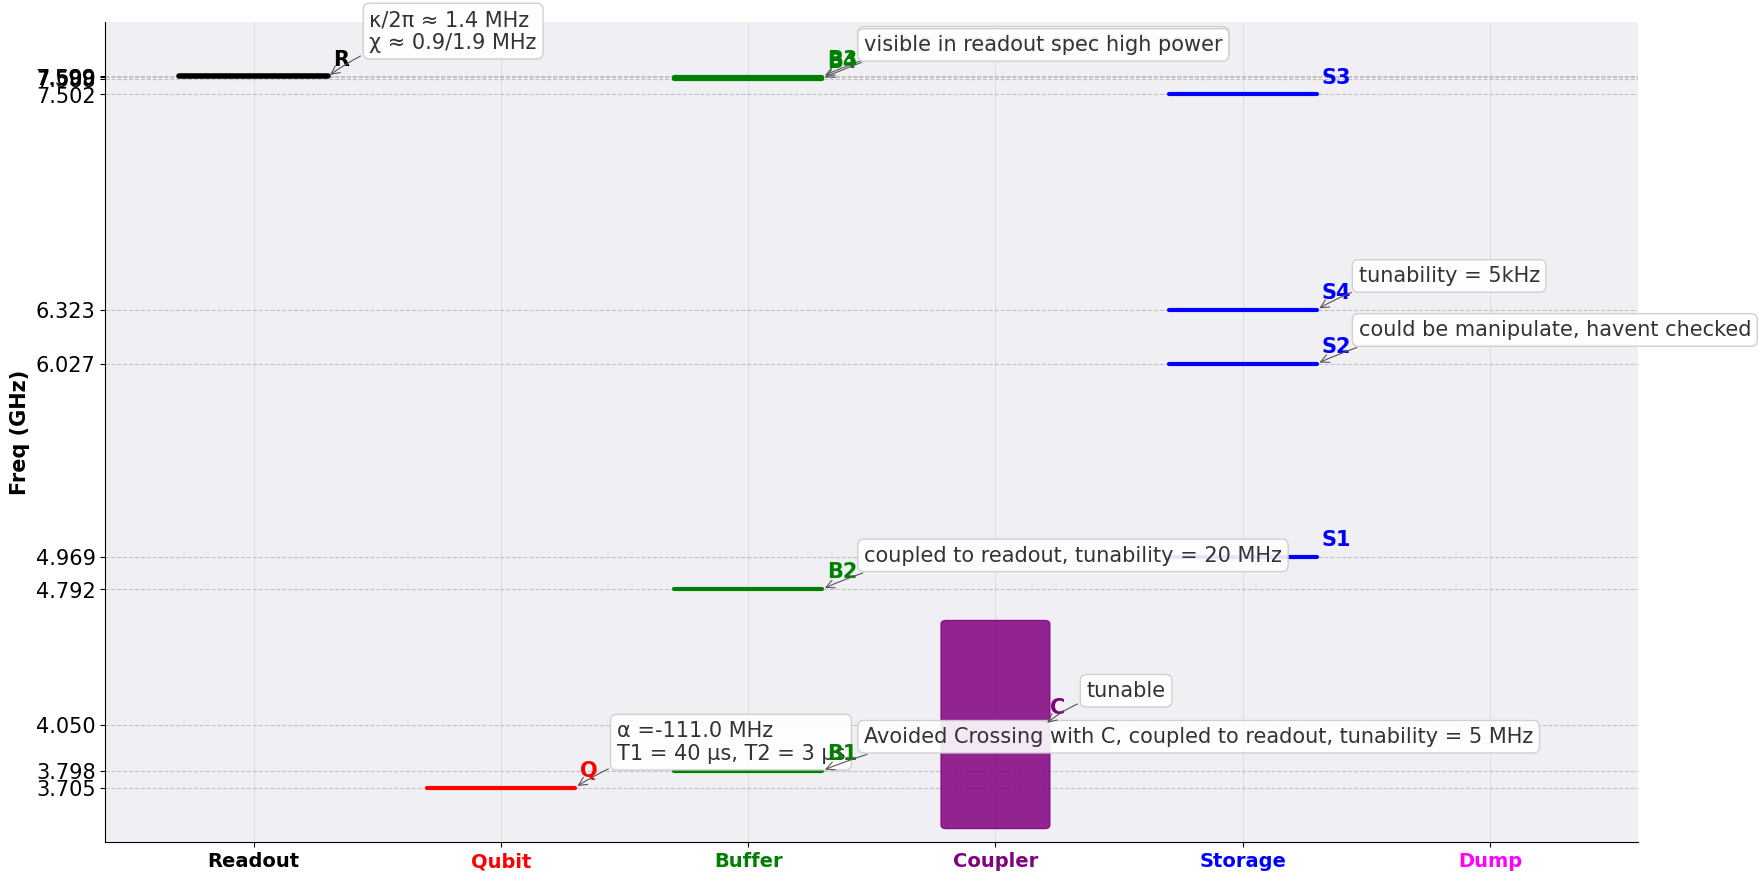

Saved: frequency_level_diagram.png, frequency_level_diagram.pdf


In [16]:
"""
Frequency level diagram for superconducting circuit modes — with annotations.

Each mode can carry:
  - 'label':  short name shown next to the line (e.g. "R1", "S3", "Q")
  - 'annotate': longer note drawn with an arrow (e.g. "χ = −1.13 MHz")

Usage:
    Edit the `modes` dictionary below.  Each frequency entry can be:
        • a plain number:              5.505
        • a dict with metadata:        {'f': 5.505, 'label': 'S1', 'annotate': 'χ = −0.28 MHz'}

    Run:  python frequency_level_diagram.py
"""

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ============================================================
# DATA — edit these for your system
# ============================================================
# Frequencies can be plain floats OR dicts with keys:
#   'f'        : frequency in GHz  (required)
#   'label'    : short text placed right of the line
#   'annotate' : longer text with an arrow pointing to the line

modes = {
    'Readout': {
        'freqs': [
            {'f': 7.6004, 'label': 'R', 'annotate': 'κ/2π ≈ 1.4 MHz' + '\nχ ≈ 0.9/1.9 MHz'},
        ],
        'color': 'black',
        'linewidth': 4,
    },
    'Qubit': {
        'freqs': [
            {'f': config_thisrun.device.qubit.f_ge/1e3, 'label': 'Q', 'annotate': 'α =' + str(np.round(config_thisrun.device.qubit.f_ef - config_thisrun.device.qubit.f_ge, 0)) + ' MHz' + 
                                                            '\nT1 = 40 μs, T2 = 3 μs'},
        ],
        'color': 'red',
        'linewidth': 3,
    },
    'Buffer': {
        'freqs': [
            {'f': 3.798, 'label': 'B1', 'annotate': 'Avoided Crossing with C, coupled to readout, tunability = 5 MHz'},
            {'f': 4.792, 'label': 'B2', 'annotate': 'coupled to readout, tunability = 20 MHz'},
            {'f':7.5995, 'label': 'B3', 'annotate': 'visible in readout spec high power'},
            {'f': 7.5882, 'label': 'B4', 'annotate': 'visible in readout spec high power'}
        ],
        'color': 'green',
        'linewidth': 3,
    },
    'Coupler': {
        'freqs': None,          # drawn as rectangle
        'band': [3.5, 4.6],   # frequency range
        'band_label': 'C',      # label for the band
        'band_annotate': 'tunable',
        'color': 'purple',
    },
    'Storage': {  
        'freqs': [
            {'f': 4.969080, 'label': 'S1'},
            {'f':6.026780, 'label': 'S2', 'annotate': 'could be manipulate, havent checked'},
            {'f': 7.502196, 'label': 'S3'},
            {'f': 6.32265, 'label': 'S4', 'annotate': 'tunability = 5kHz'},
            # {'f': 6.229, 'label': 'S5'},
            # {'f': 6.407, 'label': 'S6'},
        ],
        'color': 'blue',
        'linewidth': 3,
    },
    'Dump': {
        'freqs': [
            #{'f': 7.270, 'label': 'D'},
        ],
        'color': 'magenta',
        'linewidth': 3,
    },
}

# ============================================================
# ANNOTATION STYLE SETTINGS
# ============================================================
LABEL_FONTSIZE = 15          # font size for short labels next to lines
LABEL_OFFSET_X = 0.02      # x offset from right end of line (in data coords)
LABEL_OFFSET_Y = 0.04      # y offset above line (in data coords)

ANNOT_FONTSIZE = 15          # font size for annotation text
ANNOT_OFFSET = (30, 20)    # (dx, dy) in points from the line endpoint
ANNOT_ARROW = dict(         # arrow style
    arrowstyle='->', 
    color='#555555', 
    lw=0.8,
    connectionstyle='arc3,rad=0.15',
)
ANNOT_BBOX = dict(          # text box around annotation
    boxstyle='round,pad=0.3',
    facecolor='white',
    edgecolor='#cccccc',
    alpha=0.9,
)

# ============================================================
# HELPER
# ============================================================
def parse_freq_entry(entry):
    """Return (freq, label_or_None, annotate_or_None) from a freq entry."""
    if isinstance(entry, (int, float)):
        return float(entry), None, None
    return entry['f'], entry.get('label'), entry.get('annotate')

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(18, 9))

categories = list(modes.keys())
n_cat = len(categories)
x_positions = {cat: i for i, cat in enumerate(categories)}
line_half_width = 0.3
all_freqs = []

for cat, props in modes.items():
    xc = x_positions[cat]

    # --- Coupler (rectangle) ---
    if cat == 'Coupler' and props.get('band') is not None:
        f_lo, f_hi = props['band']
        rect_hw = 0.2
        rect = patches.FancyBboxPatch(
            (xc - rect_hw, f_lo), 2 * rect_hw, f_hi - f_lo,
            boxstyle="round,pad=0.02",
            facecolor=props['color'], edgecolor=props['color'], alpha=0.85,
        )
        ax.add_patch(rect)
        f_mid = (f_lo + f_hi) / 2
        all_freqs.append(f_mid)

        # Label
        blabel = props.get('band_label')
        if blabel:
            ax.text(
                xc + rect_hw + LABEL_OFFSET_X, f_mid + LABEL_OFFSET_Y,
                blabel, fontsize=LABEL_FONTSIZE, fontweight='bold',
                color=props['color'], va='bottom', ha='left',
            )
        # Annotation
        bannot = props.get('band_annotate')
        if bannot:
            ax.annotate(
                bannot,
                xy=(xc + rect_hw, f_mid),
                xytext=ANNOT_OFFSET, textcoords='offset points',
                fontsize=ANNOT_FONTSIZE, color='#333333',
                arrowprops=ANNOT_ARROW, bbox=ANNOT_BBOX,
            )
        continue

    # --- Normal lines ---
    freqs_raw = props['freqs']
    color = props['color']
    lw = props.get('linewidth', 3)

    for entry in freqs_raw:
        f, label, annotate = parse_freq_entry(entry)

        # Draw the level line
        x_left = xc - line_half_width
        x_right = xc + line_half_width
        ax.plot(
            [x_left, x_right], [f, f],
            color=color, linewidth=lw, solid_capstyle='round',
        )
        all_freqs.append(f)

        # Short label (right of line)
        if label:
            ax.text(
                x_right + LABEL_OFFSET_X, f + LABEL_OFFSET_Y,
                label, fontsize=LABEL_FONTSIZE, fontweight='bold',
                color=color, va='bottom', ha='left',
            )

        # Annotation with arrow
        if annotate:
            ax.annotate(
                annotate,
                xy=(x_right, f),
                xytext=ANNOT_OFFSET, textcoords='offset points',
                fontsize=ANNOT_FONTSIZE, color='#333333',
                arrowprops=ANNOT_ARROW, bbox=ANNOT_BBOX,
            )

# ---- Formatting ----
ax.set_xticks(range(n_cat))
ax.set_xticklabels(categories, fontsize=14, fontweight='bold')
for i, cat in enumerate(categories):
    ax.get_xticklabels()[i].set_color(modes[cat]['color'])

ax.set_xlim(-0.6, n_cat - 0.4)

unique_freqs = sorted(set(all_freqs))
ax.set_yticks(unique_freqs)
ax.set_yticklabels([f'{f:.3f}' for f in unique_freqs], fontsize=15)
ax.set_ylabel('Freq (GHz)', fontsize=15, fontweight='bold')

y_margin = 0.3
ax.set_ylim(min(unique_freqs) - y_margin, max(unique_freqs) + y_margin)

ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='gray')
ax.xaxis.grid(True, linestyle='-', alpha=0.15, color='gray')
ax.set_axisbelow(True)
ax.set_facecolor('#f0f0f4')
fig.patch.set_facecolor('white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('frequency_level_diagram.png', dpi=200, bbox_inches='tight')
plt.savefig('frequency_level_diagram.pdf', bbox_inches='tight')
plt.show()

print("Saved: frequency_level_diagram.png, frequency_level_diagram.pdf")

In [12]:
config_thisrun.device.qubit.f_ge + config_thisrun.device.qubit.f_ef - 2650

4648.5204